# Steam Games – Preparación & Análisis Exploratorio de Datos
### Proyecto: ¿Será un juego exitoso en base a sus tags?

Este notebook cubre dos etapas:
1. **Preparación inicial** – limpieza, tratamiento de nulos, encoding de tags
2. **Análisis exploratorio (EDA)** – distribuciones, outliers, relaciones y calidad del dataset


## 0. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Paleta de colores
BLUE   = '#4A90D9'
ORANGE = '#E07B39'
GREEN  = '#5BAD72'
RED    = '#D94A4A'
PURPLE = '#7B5BAD'
TEAL   = '#3AADA8'
BG     = '#F7F9FC'
DARK   = '#1E2A3A'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor':   DARK, 'axes.labelcolor': DARK,
    'xtick.color':      DARK, 'ytick.color':     DARK,
    'text.color':       DARK, 'font.family':     'DejaVu Sans',
    'axes.spines.top':  False, 'axes.spines.right': False,
})

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


---
## 1. Preparación inicial del dataset

Antes de explorar los datos, realizamos una limpieza básica:
- Filtrar solo registros de tipo **game**
- Eliminar **duplicados** por AppID
- **Descartar columnas** no relevantes para el objetivo
- Tratar **valores faltantes**
- Crear nuevas variables derivadas
- Hacer **One-Hot Encoding** de los tags


### 1.1 Carga y primera vista

In [2]:
INPUT_FILE       = 'SteamGames_cleaned.csv'
TAG_FREQ_MIN     = 50   # tags con menos apariciones se descartan
REVIEW_THRESHOLD = 7    # ReviewScore >= 7 → juego "exitoso"

df_raw = pd.read_csv(INPUT_FILE)
print(f"Dimensiones originales: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)


Dimensiones originales: 29,905 filas × 21 columnas


,Appid,Name,Type,ReleaseDate,Genres,Developers,Publishers,Description,price,Thumbnail,...,ReviewScore,PositiveReview,NegativeReview,OsRequirement,MemoryRequirement,Rank,CPU_req,CPU_GHz,CPU_tier,tags
0,3764200,Resident Evil Requiem,game,2026-02-26,"Action,Adventure","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.",Resident Evil Requiem Deluxe Edition Resident ...,69.99,https://shared.akamai.steamstatic.com/store_it...,...,9,23715,793,['no requirement'],0.0,1,0.0,0.0,0.0,"action, adventure"
1,730,Counter-Strike 2,game,2012-08-21,"Action,Free To Play",Valve,Valve,"For over two decades, Counter-Strike has offer...",0.00,https://shared.akamai.steamstatic.com/store_it...,...,8,1214897,202393,['windows'],8192.0,2,1.0,3.0,2.0,"action, strategy, multiplayer, first-person, s..."
2,1808500,ARC Raiders,game,2025-10-30,Action,Embark Studios,Embark Studios,ARC Raiders Deluxe Edition ARC Raiders Deluxe ...,39.99,https://shared.akamai.steamstatic.com/store_it...,...,8,149531,23194,['windows'],12288.0,3,1.0,3.0,2.0,"action, atmospheric, multiplayer, shooter, sci..."


### 1.2 Tipos de datos y valores faltantes

In [3]:
print("Tipos de datos:")
print(df_raw.dtypes)
print()
print("Valores faltantes por columna:")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])


Tipos de datos:
Appid                  int64
Name                     str
Type                     str
ReleaseDate              str
Genres                   str
Developers               str
Publishers               str
Description              str
price                float64
Thumbnail                str
Tags                     str
ReviewScore            int64
PositiveReview         int64
NegativeReview         int64
OsRequirement            str
MemoryRequirement    float64
Rank                   int64
CPU_req              float64
CPU_GHz              float64
CPU_tier             float64
tags                     str
dtype: object

Valores faltantes por columna:
Name                  25
Genres               406
Developers           234
Publishers           165
Tags                 229
MemoryRequirement     45
tags                 287
dtype: int64


### 1.3 Filtro: solo juegos

In [4]:
print("Distribución columna 'Type':")
print(df_raw['Type'].value_counts())

df = df_raw[df_raw['Type'] == 'game'].copy()
print(f"\nTras filtrar type=game: {df.shape[0]:,} filas")


Distribución columna 'Type':
Type
game     22699
dlc       6582
music      597
mod         26
video        1
Name: count, dtype: int64

Tras filtrar type=game: 22,699 filas


### 1.4 Eliminación de duplicados por AppID

In [5]:
dups = df['Appid'].duplicated().sum()
print(f"AppIDs duplicados: {dups}")
df = df.drop_duplicates(subset='Appid', keep='first').reset_index(drop=True)
print(f"Tras eliminar duplicados: {df.shape[0]:,} filas")


AppIDs duplicados: 105
Tras eliminar duplicados: 22,594 filas


### 1.5 Descarte de columnas

| Columna | Motivo de descarte |
|---|---|
| `Thumbnail` | URL, no aporta al modelo |
| `Description` | Texto libre, requiere NLP por separado |
| `Tags` (mayúscula) | Versión cruda; usamos `tags` (minúscula, ya limpia) |
| `Genres` | Redundante con tags para nuestro objetivo |
| `OsRequirement` | Texto no estructurado, alta varianza |


In [6]:
df.drop(columns=['Thumbnail', 'Description', 'Tags', 'OsRequirement', 'Genres'],
        inplace=True)
print(f"Columnas restantes: {df.shape[1]}")
print(df.columns.tolist())


Columnas restantes: 16
['Appid', 'Name', 'Type', 'ReleaseDate', 'Developers', 'Publishers', 'price', 'ReviewScore', 'PositiveReview', 'NegativeReview', 'MemoryRequirement', 'Rank', 'CPU_req', 'CPU_GHz', 'CPU_tier', 'tags']


### 1.6 Tratamiento de valores faltantes

In [7]:
# Name: sin nombre no podemos identificar el juego → eliminar fila
antes = df.shape[0]
df = df[df['Name'].notna()].copy()
print(f"Filas eliminadas por Name nulo: {antes - df.shape[0]}")

# Developers / Publishers → rellenar con 'Unknown'
df['Developers'] = df['Developers'].fillna('Unknown')
df['Publishers']  = df['Publishers'].fillna('Unknown')
print("Developers/Publishers: nulos reemplazados con 'Unknown'")

# MemoryRequirement → imputar con mediana
mediana_mem = df['MemoryRequirement'].median()
df['MemoryRequirement'] = df['MemoryRequirement'].fillna(mediana_mem)
print(f"MemoryRequirement: imputado con mediana ({mediana_mem:.0f} MB)")

# tags: sin tags no podemos hacer la predicción → eliminar fila
antes = df.shape[0]
df = df[df['tags'].notna()].copy()
print(f"Filas eliminadas por tags nulo: {antes - df.shape[0]}")

print(f"\nNulos remanentes: {df.isnull().sum().sum()}")


Filas eliminadas por Name nulo: 21
Developers/Publishers: nulos reemplazados con 'Unknown'
MemoryRequirement: imputado con mediana (4096 MB)
Filas eliminadas por tags nulo: 42

Nulos remanentes: 0


### 1.7 Transformaciones

In [8]:
# Fecha como datetime
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce')
df['ReleaseYear'] = df['ReleaseDate'].dt.year

# Variable objetivo
df['Exitoso'] = (df['ReviewScore'] >= REVIEW_THRESHOLD).astype(int)

# Total reseñas y ratio positivo
df['TotalReviews'] = df['PositiveReview'] + df['NegativeReview']
df['PositiveRatio'] = np.where(
    df['TotalReviews'] > 0,
    df['PositiveReview'] / df['TotalReviews'],
    np.nan
)

print("Variables creadas: ReleaseYear, Exitoso, TotalReviews, PositiveRatio")
df[['ReviewScore','Exitoso','TotalReviews','PositiveRatio']].describe()


Variables creadas: ReleaseYear, Exitoso, TotalReviews, PositiveRatio


,ReviewScore,Exitoso,TotalReviews,PositiveRatio
count,22531.000000,22531.000000,2.253100e+04,21721.000000
mean,6.601216,0.688119,2.137044e+03,0.855672
std,2.334404,0.463272,1.763799e+04,0.119417
min,0.000000,0.000000,0.000000e+00,0.000000
25%,6.000000,0.000000,3.300000e+01,0.800000
50%,8.000000,1.000000,1.110000e+02,0.879195
75%,8.000000,1.000000,5.140000e+02,0.941320
max,9.000000,1.000000,1.417290e+06,1.000000


### 1.8 One-Hot Encoding de Tags

In [9]:
# Contar frecuencia de todos los tags
all_tags = []
for row in df['tags']:
    all_tags.extend([t.strip() for t in row.split(',')])
tag_counts = Counter(all_tags)

selected_tags = [t for t, c in tag_counts.items() if c >= TAG_FREQ_MIN]
print(f"Tags totales únicos: {len(tag_counts)}")
print(f"Tags seleccionados (freq >= {TAG_FREQ_MIN}): {len(selected_tags)}")
print(f"Tags descartados por baja frecuencia: {len(tag_counts) - len(selected_tags)}")

# Crear columnas binarias
tag_data = {}
for tag in selected_tags:
    col = 'tag_' + tag.replace(' ', '_').replace('-', '_')
    tag_data[col] = df['tags'].apply(
        lambda x: 1 if tag in [t.strip() for t in x.split(',')] else 0
    )
df = pd.concat([df, pd.DataFrame(tag_data, index=df.index)], axis=1)

tag_cols = [c for c in df.columns if c.startswith('tag_')]
print(f"\nColumnas tag_* creadas: {len(tag_cols)}")
print("Ejemplo:", tag_cols[:5])


Tags totales únicos: 200
Tags seleccionados (freq >= 50): 134
Tags descartados por baja frecuencia: 66

Columnas tag_* creadas: 134
Ejemplo: ['tag_action', 'tag_adventure', 'tag_strategy', 'tag_multiplayer', 'tag_first_person']


### 1.9 Resumen del dataset final

In [10]:
print(f"{'='*50}")
print(f"DATASET FINAL: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Columnas de tags   : {len(tag_cols)}")
print(f"  Exitoso (1)        : {df['Exitoso'].sum():,}  ({df['Exitoso'].mean()*100:.1f}%)")
print(f"  No exitoso (0)     : {(df['Exitoso']==0).sum():,}  ({(1-df['Exitoso'].mean())*100:.1f}%)")
print(f"  Nulos remanentes   : {df.isnull().sum().sum()}")
print(f"{'='*50}")

df.to_csv('SteamGames_prepared.csv', index=False)
print("\nDataset guardado como SteamGames_prepared.csv")


DATASET FINAL: 22,531 filas × 154 columnas
  Columnas de tags   : 134
  Exitoso (1)        : 15,504  (68.8%)
  No exitoso (0)     : 7,027  (31.2%)
  Nulos remanentes   : 810

Dataset guardado como SteamGames_prepared.csv


---
## 2. Análisis Exploratorio de Datos (EDA)

Con el dataset limpio exploramos:
- Distribución de variables importantes
- Detección de outliers
- Relación entre variables y la variable objetivo
- Calidad del dataset resultante


### 2.1 Visión general

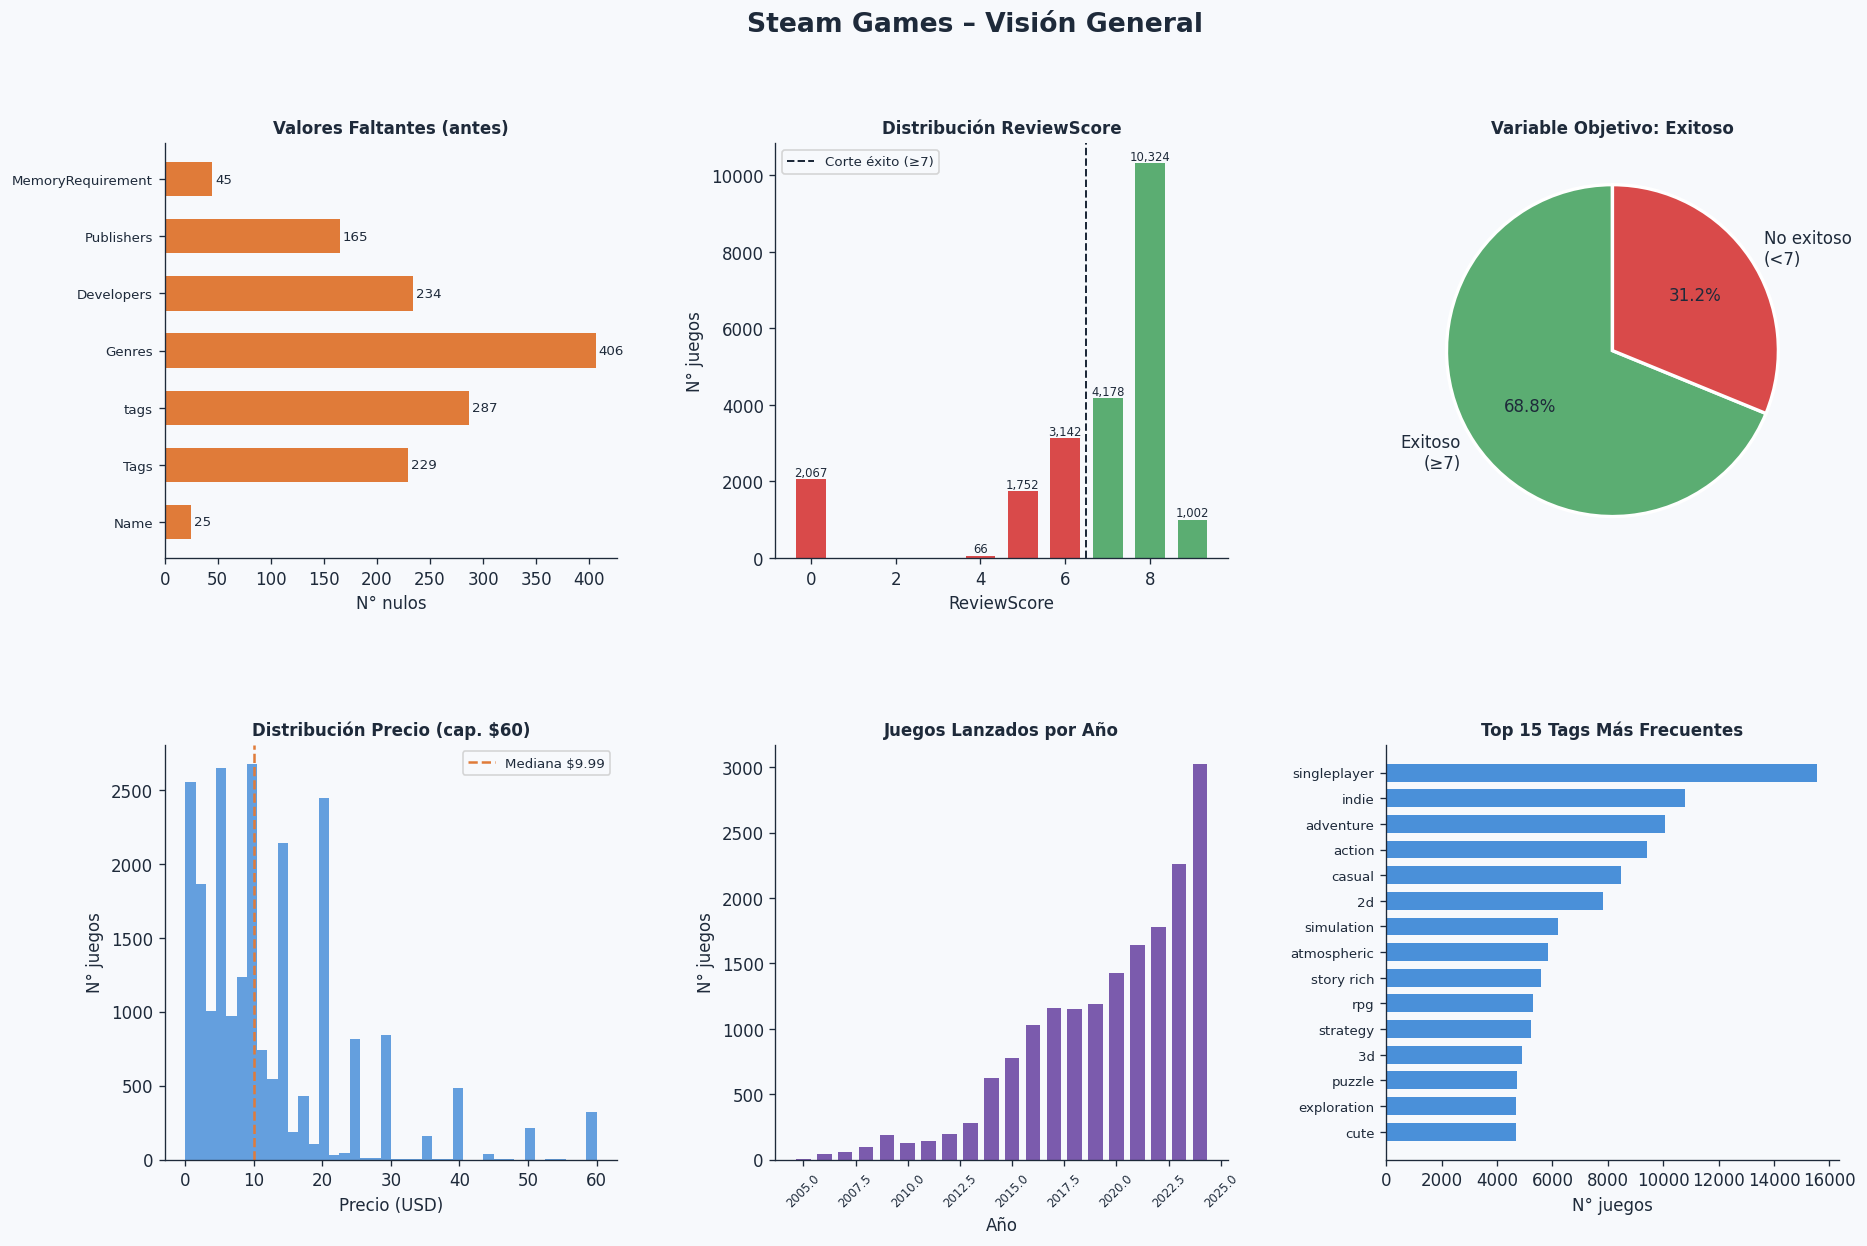

In [11]:
df['n_tags'] = df[tag_cols].sum(axis=1)

fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.suptitle('Steam Games – Visión General', fontsize=16, fontweight='bold', color=DARK, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Valores faltantes antes
ax = fig.add_subplot(gs[0, 0])
missing_before = {'Name':25,'Tags':229,'tags':287,'Genres':406,'Developers':234,'Publishers':165,'MemoryRequirement':45}
bars = ax.barh(list(missing_before.keys()), list(missing_before.values()), color=ORANGE, edgecolor='none', height=0.6)
ax.set_title('Valores Faltantes (antes)', fontsize=10, fontweight='bold')
ax.set_xlabel('N° nulos')
for bar, v in zip(bars, missing_before.values()):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# ReviewScore
ax = fig.add_subplot(gs[0, 1])
vc = df['ReviewScore'].value_counts().sort_index()
colors_rs = [RED if i < 7 else GREEN for i in vc.index]
bars2 = ax.bar(vc.index, vc.values, color=colors_rs, edgecolor='none', width=0.7)
ax.set_title('Distribución ReviewScore', fontsize=10, fontweight='bold')
ax.set_xlabel('ReviewScore'); ax.set_ylabel('N° juegos')
ax.axvline(6.5, color=DARK, linestyle='--', linewidth=1.2, label='Corte éxito (≥7)')
ax.legend(fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80, f'{bar.get_height():,.0f}', ha='center', fontsize=7)

# Variable objetivo
ax = fig.add_subplot(gs[0, 2])
counts = df['Exitoso'].value_counts()
ax.pie(counts, labels=['Exitoso\n(≥7)','No exitoso\n(<7)'], autopct='%1.1f%%',
       colors=[GREEN, RED], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Variable Objetivo: Exitoso', fontsize=10, fontweight='bold')

# Precio
ax = fig.add_subplot(gs[1, 0])
ax.hist(df['price'].clip(upper=60), bins=40, color=BLUE, edgecolor='none', alpha=0.85)
ax.set_title('Distribución Precio (cap. $60)', fontsize=10, fontweight='bold')
ax.set_xlabel('Precio (USD)'); ax.set_ylabel('N° juegos')
ax.axvline(df['price'].median(), color=ORANGE, linestyle='--', linewidth=1.5, label=f'Mediana ${df["price"].median()}')
ax.legend(fontsize=8)

# Juegos por año
ax = fig.add_subplot(gs[1, 1])
year_counts = df[df['ReleaseYear'].between(2005,2024)]['ReleaseYear'].value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color=PURPLE, edgecolor='none', width=0.7)
ax.set_title('Juegos Lanzados por Año', fontsize=10, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('N° juegos')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# Top 15 tags
ax = fig.add_subplot(gs[1, 2])
tag_freq = df[tag_cols].sum().sort_values(ascending=True).tail(15)
tag_labels = [c.replace('tag_','').replace('_',' ') for c in tag_freq.index]
ax.barh(tag_labels, tag_freq.values, color=BLUE, edgecolor='none', height=0.7)
ax.set_title('Top 15 Tags Más Frecuentes', fontsize=10, fontweight='bold')
ax.set_xlabel('N° juegos'); ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


**Observaciones:**
- El ReviewScore se concentra en 6–8, con mayoría de juegos "buenos" o mejor.
- El precio tiene distribución muy sesgada a la derecha (muchos juegos baratos, pocos caros).
- El crecimiento de lanzamientos es exponencial desde 2013, con peak cerca de 2022.
- Tags dominantes: `singleplayer`, `indie`, `action`, `adventure` — representan el grueso del catálogo.


### 2.2 Distribuciones y detección de outliers

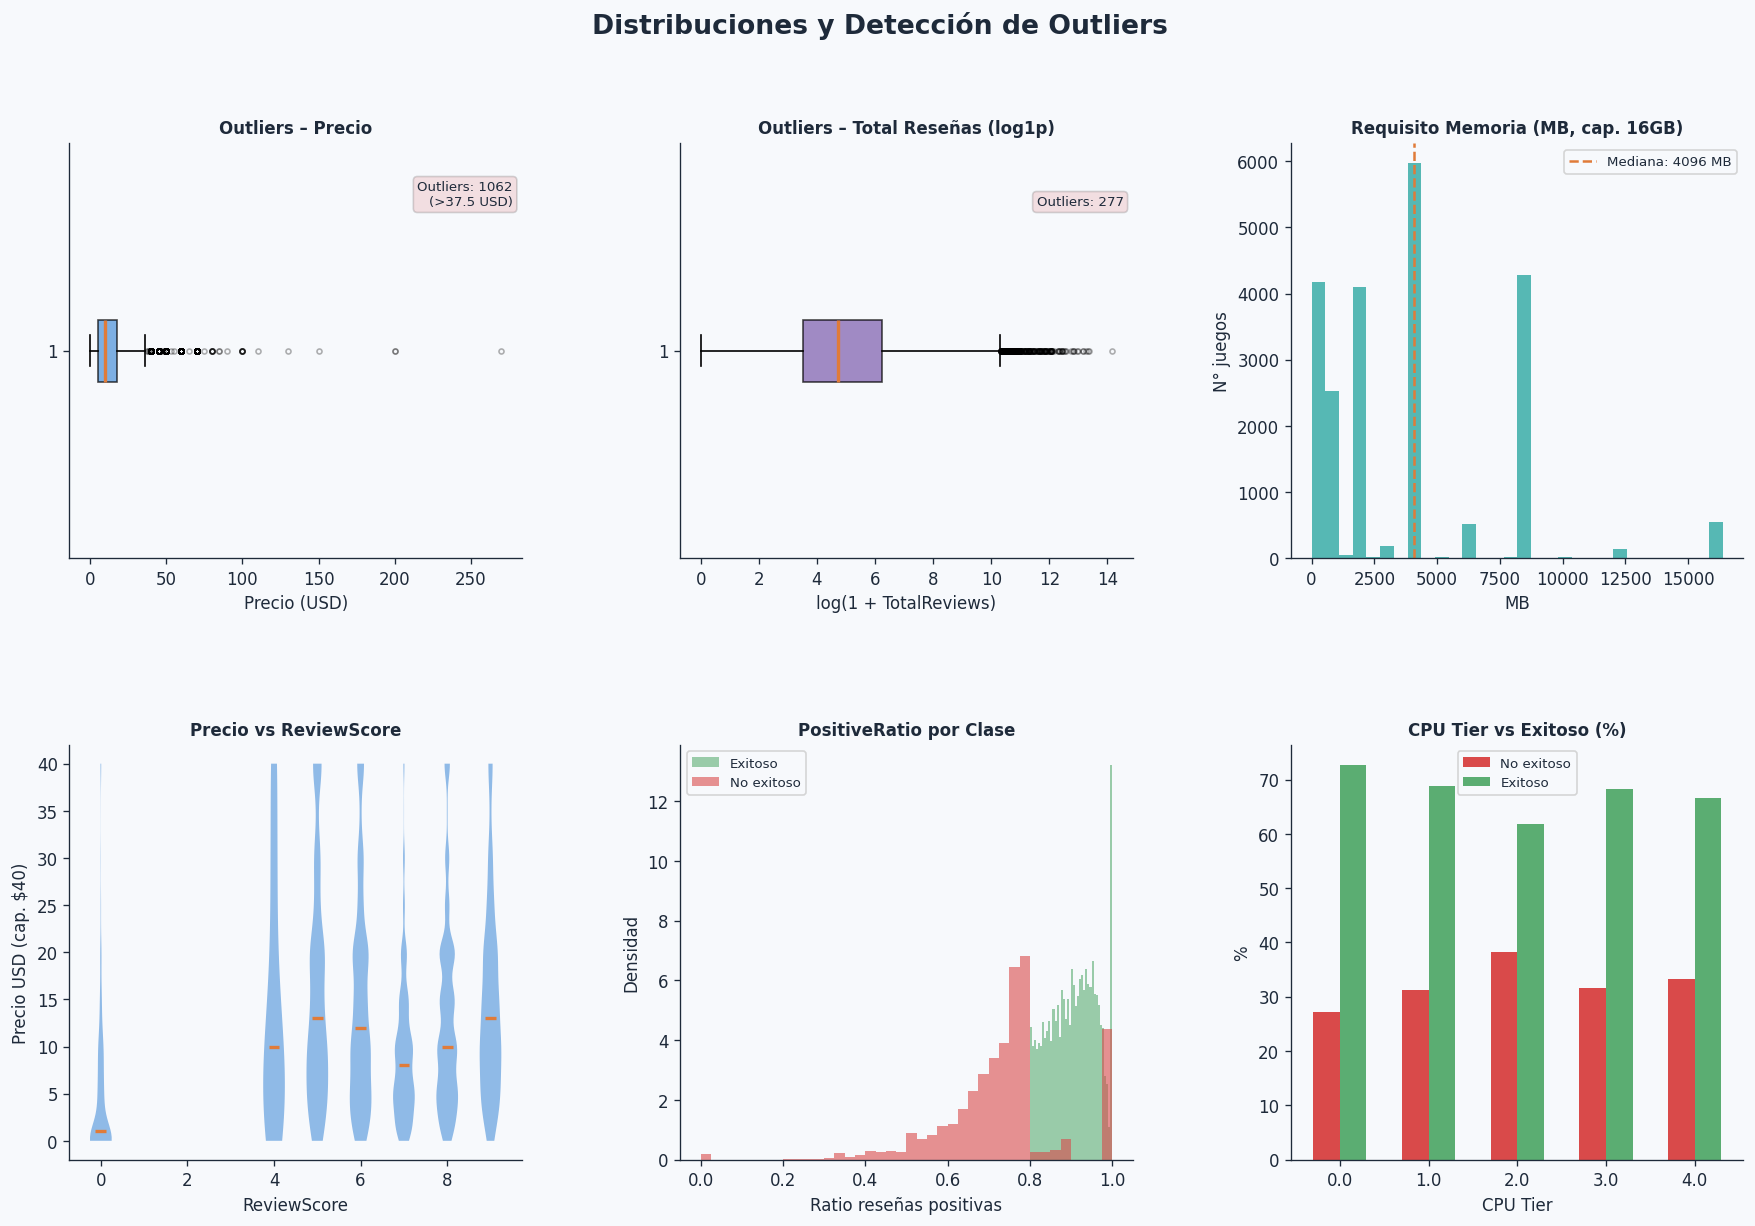

In [12]:
fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.suptitle('Distribuciones y Detección de Outliers', fontsize=16, fontweight='bold', color=DARK, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Boxplot precio
ax = fig.add_subplot(gs[0, 0])
ax.boxplot(df['price'], vert=False, patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.7),
           medianprops=dict(color=ORANGE, linewidth=2),
           flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
ax.set_title('Outliers – Precio', fontsize=10, fontweight='bold'); ax.set_xlabel('Precio (USD)')
q1, q3 = df['price'].quantile([.25,.75]); upper_fence = q3 + 1.5*(q3-q1)
outliers_price = (df['price'] > upper_fence).sum()
ax.text(0.98,0.85,f'Outliers: {outliers_price}\n(>{upper_fence:.1f} USD)',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=RED, alpha=0.15))

# Boxplot reseñas (log)
ax = fig.add_subplot(gs[0, 1])
total_rev_log = np.log1p(df['TotalReviews'])
ax.boxplot(total_rev_log, vert=False, patch_artist=True,
           boxprops=dict(facecolor=PURPLE, alpha=0.7),
           medianprops=dict(color=ORANGE, linewidth=2),
           flierprops=dict(marker='o', color=RED, alpha=0.3, markersize=3))
ax.set_title('Outliers – Total Reseñas (log1p)', fontsize=10, fontweight='bold')
ax.set_xlabel('log(1 + TotalReviews)')
q1r, q3r = total_rev_log.quantile([.25,.75])
out_rev = (total_rev_log > q3r + 1.5*(q3r-q1r)).sum()
ax.text(0.98,0.85,f'Outliers: {out_rev}', transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=RED, alpha=0.15))

# Memoria
ax = fig.add_subplot(gs[0, 2])
ax.hist(df['MemoryRequirement'].clip(upper=16384), bins=30, color=TEAL, edgecolor='none', alpha=0.85)
ax.set_title('Requisito Memoria (MB, cap. 16GB)', fontsize=10, fontweight='bold')
ax.set_xlabel('MB'); ax.set_ylabel('N° juegos')
ax.axvline(df['MemoryRequirement'].median(), color=ORANGE, linestyle='--', linewidth=1.5,
           label=f'Mediana: {df["MemoryRequirement"].median():.0f} MB')
ax.legend(fontsize=8)

# Violín precio vs score
ax = fig.add_subplot(gs[1, 0])
scores = sorted(df['ReviewScore'].unique())
data_violin = [df[df['ReviewScore']==s]['price'].clip(upper=40).values for s in scores]
parts = ax.violinplot(data_violin, positions=scores, showmedians=True, showextrema=False)
for pc in parts['bodies']: pc.set_facecolor(BLUE); pc.set_alpha(0.6)
parts['cmedians'].set_color(ORANGE); parts['cmedians'].set_linewidth(2)
ax.set_title('Precio vs ReviewScore', fontsize=10, fontweight='bold')
ax.set_xlabel('ReviewScore'); ax.set_ylabel('Precio USD (cap. $40)')

# PositiveRatio por clase
ax = fig.add_subplot(gs[1, 1])
df_r = df[df['PositiveRatio'].notna()]
ax.hist(df_r[df_r['Exitoso']==1]['PositiveRatio'], bins=40, alpha=0.6, color=GREEN, label='Exitoso', density=True)
ax.hist(df_r[df_r['Exitoso']==0]['PositiveRatio'], bins=40, alpha=0.6, color=RED, label='No exitoso', density=True)
ax.set_title('PositiveRatio por Clase', fontsize=10, fontweight='bold')
ax.set_xlabel('Ratio reseñas positivas'); ax.set_ylabel('Densidad'); ax.legend(fontsize=8)

# CPU_tier vs Exitoso
ax = fig.add_subplot(gs[1, 2])
ct_pct = (df.groupby(['CPU_tier','Exitoso']).size()
           .unstack(fill_value=0)
           .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100))
ct_pct.plot(kind='bar', ax=ax, color=[RED,GREEN], edgecolor='none', width=0.6)
ax.set_title('CPU Tier vs Exitoso (%)', fontsize=10, fontweight='bold')
ax.set_xlabel('CPU Tier'); ax.set_ylabel('%')
ax.legend(['No exitoso','Exitoso'], fontsize=8); ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Observaciones:**
- El precio tiene outliers significativos sobre ~$27 (fence IQR). Son reales, no errores (juegos premium/AAA).
- El total de reseñas es muy asimétrico incluso en log — hay juegos con millones de reseñas (CS:GO, etc.).
- El `PositiveRatio` separa bien las clases: los exitosos tienen ratio muy concentrado en valores altos.
- El `CPU_tier` no parece tener relación clara con el éxito — poca varianza entre tiers.


### 2.3 Relación entre variables

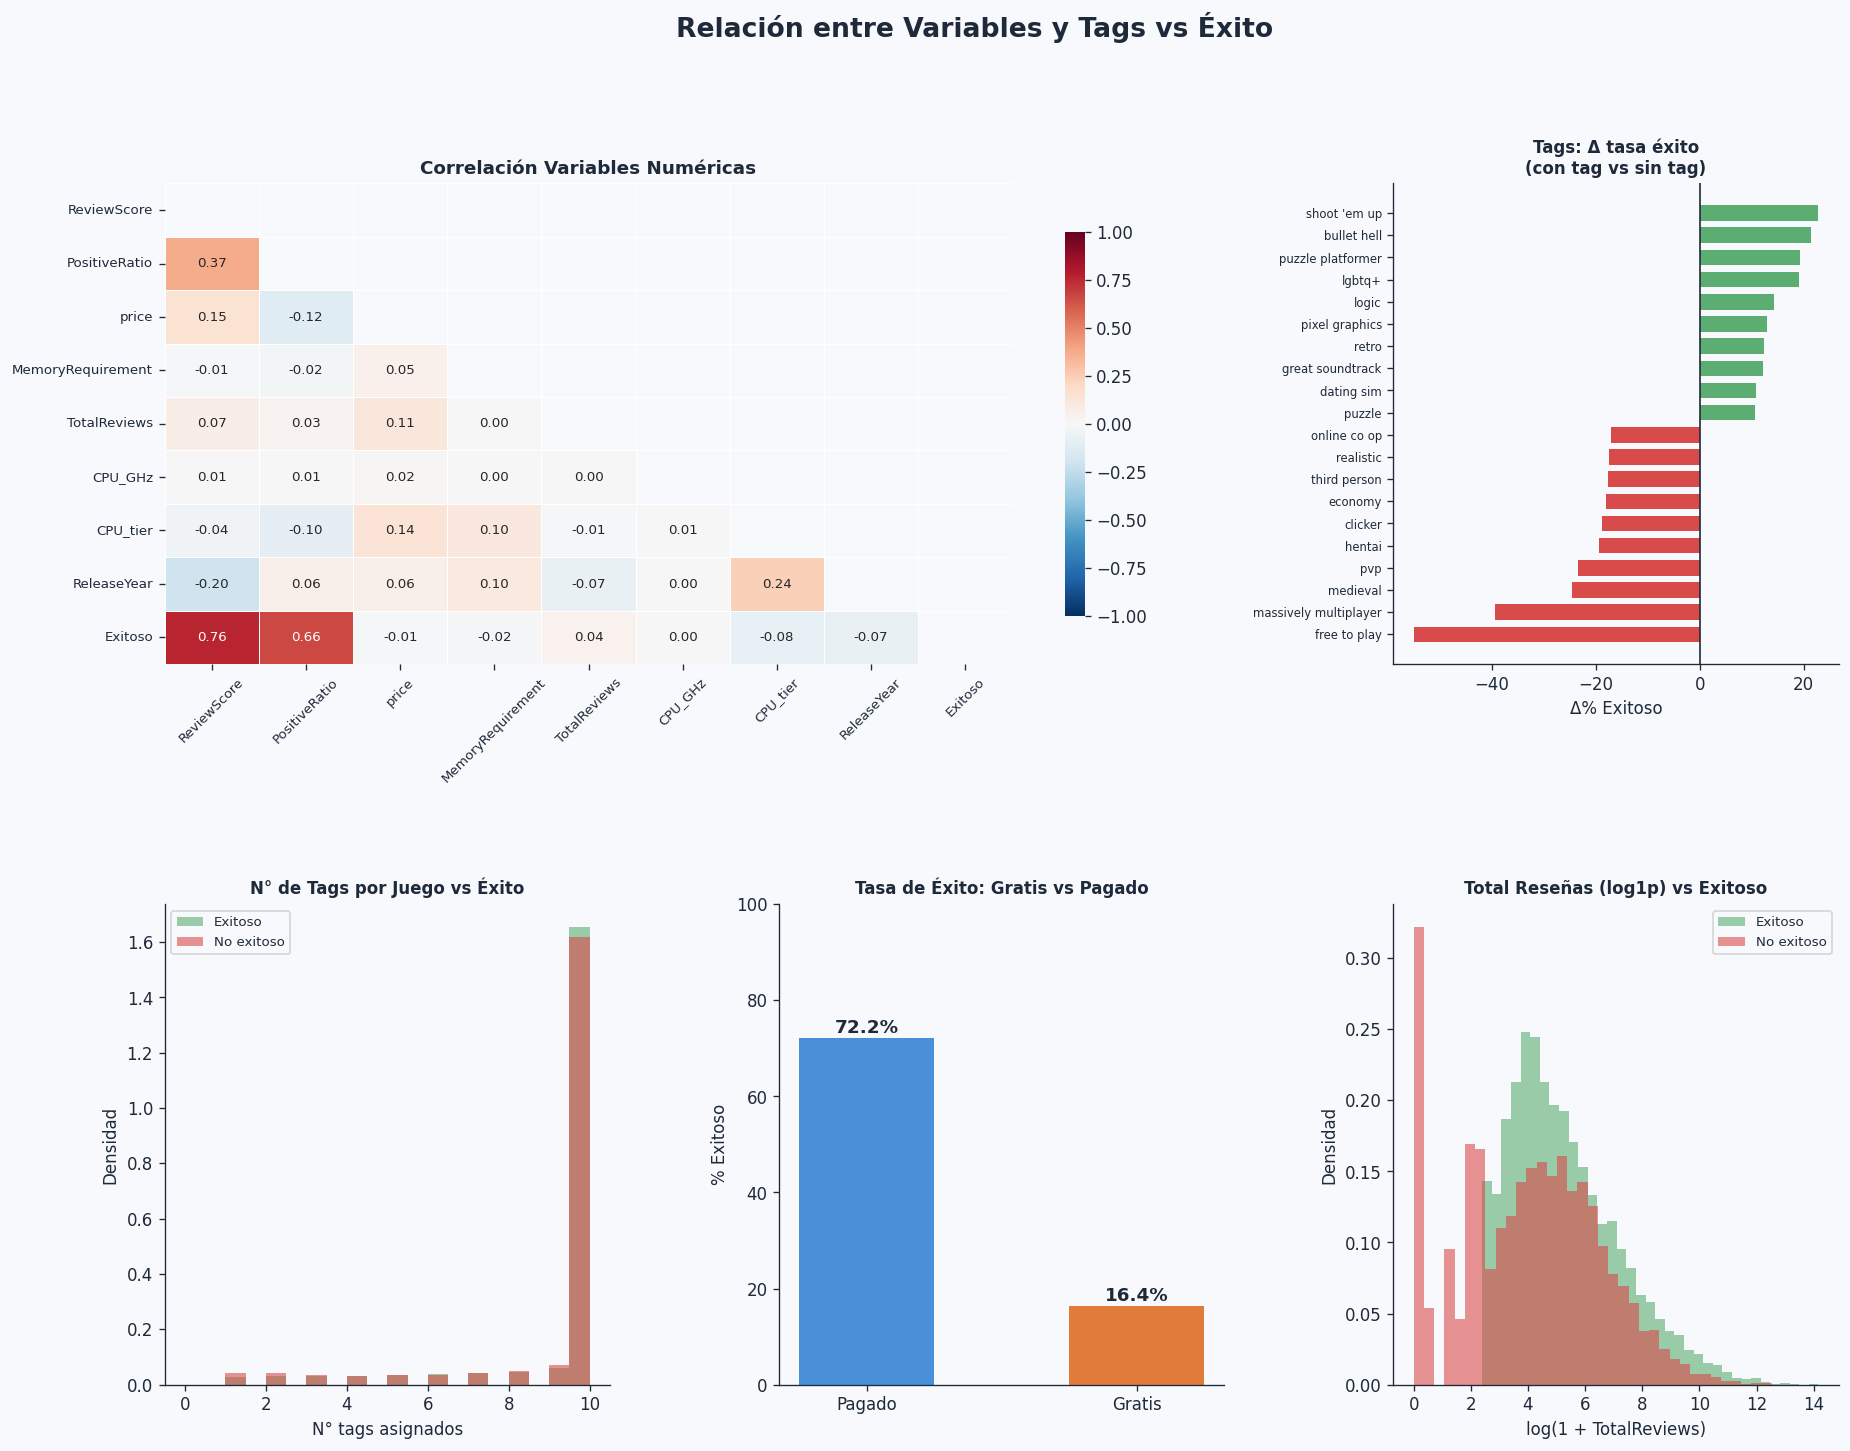

In [13]:
fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle('Relación entre Variables y Tags vs Éxito', fontsize=16, fontweight='bold', color=DARK, y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# Heatmap correlación
ax = fig.add_subplot(gs[0, :2])
num_cols = ['ReviewScore','PositiveRatio','price','MemoryRequirement',
            'TotalReviews','CPU_GHz','CPU_tier','ReleaseYear','Exitoso']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size':8}, cbar_kws={'shrink':0.8})
ax.set_title('Correlación Variables Numéricas', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# Tags: diferencia tasa de éxito
ax = fig.add_subplot(gs[0, 2])
tag_success = {
    col.replace('tag_','').replace('_',' '): {
        'diff': df[df[col]==1]['Exitoso'].mean() - df[df[col]==0]['Exitoso'].mean()
    }
    for col in tag_cols
}
ts_df = pd.DataFrame(tag_success).T.sort_values('diff')
combined = pd.concat([ts_df.head(10), ts_df.tail(10)])
colors_bar = [RED if v < 0 else GREEN for v in combined['diff']]
ax.barh(combined.index, combined['diff']*100, color=colors_bar, edgecolor='none', height=0.7)
ax.axvline(0, color=DARK, linewidth=1)
ax.set_title('Tags: Δ tasa éxito\n(con tag vs sin tag)', fontsize=10, fontweight='bold')
ax.set_xlabel('Δ% Exitoso'); ax.tick_params(axis='y', labelsize=7)

# N° tags vs éxito
ax = fig.add_subplot(gs[1, 0])
ax.hist(df[df['Exitoso']==1]['n_tags'], bins=20, alpha=0.6, color=GREEN, density=True, label='Exitoso')
ax.hist(df[df['Exitoso']==0]['n_tags'], bins=20, alpha=0.6, color=RED, density=True, label='No exitoso')
ax.set_title('N° de Tags por Juego vs Éxito', fontsize=10, fontweight='bold')
ax.set_xlabel('N° tags asignados'); ax.set_ylabel('Densidad'); ax.legend(fontsize=8)

# Gratis vs pagado
ax = fig.add_subplot(gs[1, 1])
df['es_gratis'] = (df['price']==0).astype(int)
g = df.groupby('es_gratis')['Exitoso'].mean()*100
ax.bar(['Pagado','Gratis'], g.values, color=[BLUE,ORANGE], edgecolor='none', width=0.5)
ax.set_title('Tasa de Éxito: Gratis vs Pagado', fontsize=10, fontweight='bold')
ax.set_ylabel('% Exitoso'); ax.set_ylim(0,100)
for i,v in enumerate(g.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# TotalReviews log vs éxito
ax = fig.add_subplot(gs[1, 2])
ax.hist(np.log1p(df[df['Exitoso']==1]['TotalReviews']), bins=35, alpha=0.6, color=GREEN, density=True, label='Exitoso')
ax.hist(np.log1p(df[df['Exitoso']==0]['TotalReviews']), bins=35, alpha=0.6, color=RED, density=True, label='No exitoso')
ax.set_title('Total Reseñas (log1p) vs Exitoso', fontsize=10, fontweight='bold')
ax.set_xlabel('log(1 + TotalReviews)'); ax.set_ylabel('Densidad'); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Observaciones:**
- `ReviewScore` y `Exitoso` tienen correlación perfecta (esperado, ya que Exitoso se derivó de ReviewScore).
- `PositiveRatio` tiene la correlación más alta con `Exitoso` entre las variables independientes.
- Tags como `story rich`, `rpg`, `atmospheric` se asocian positivamente con el éxito.
- Tags como `free to play`, `casual`, `early access` se asocian negativamente.
- Los juegos pagados tienen tasa de éxito levemente mayor que los gratuitos.


### 2.4 Calidad del dataset

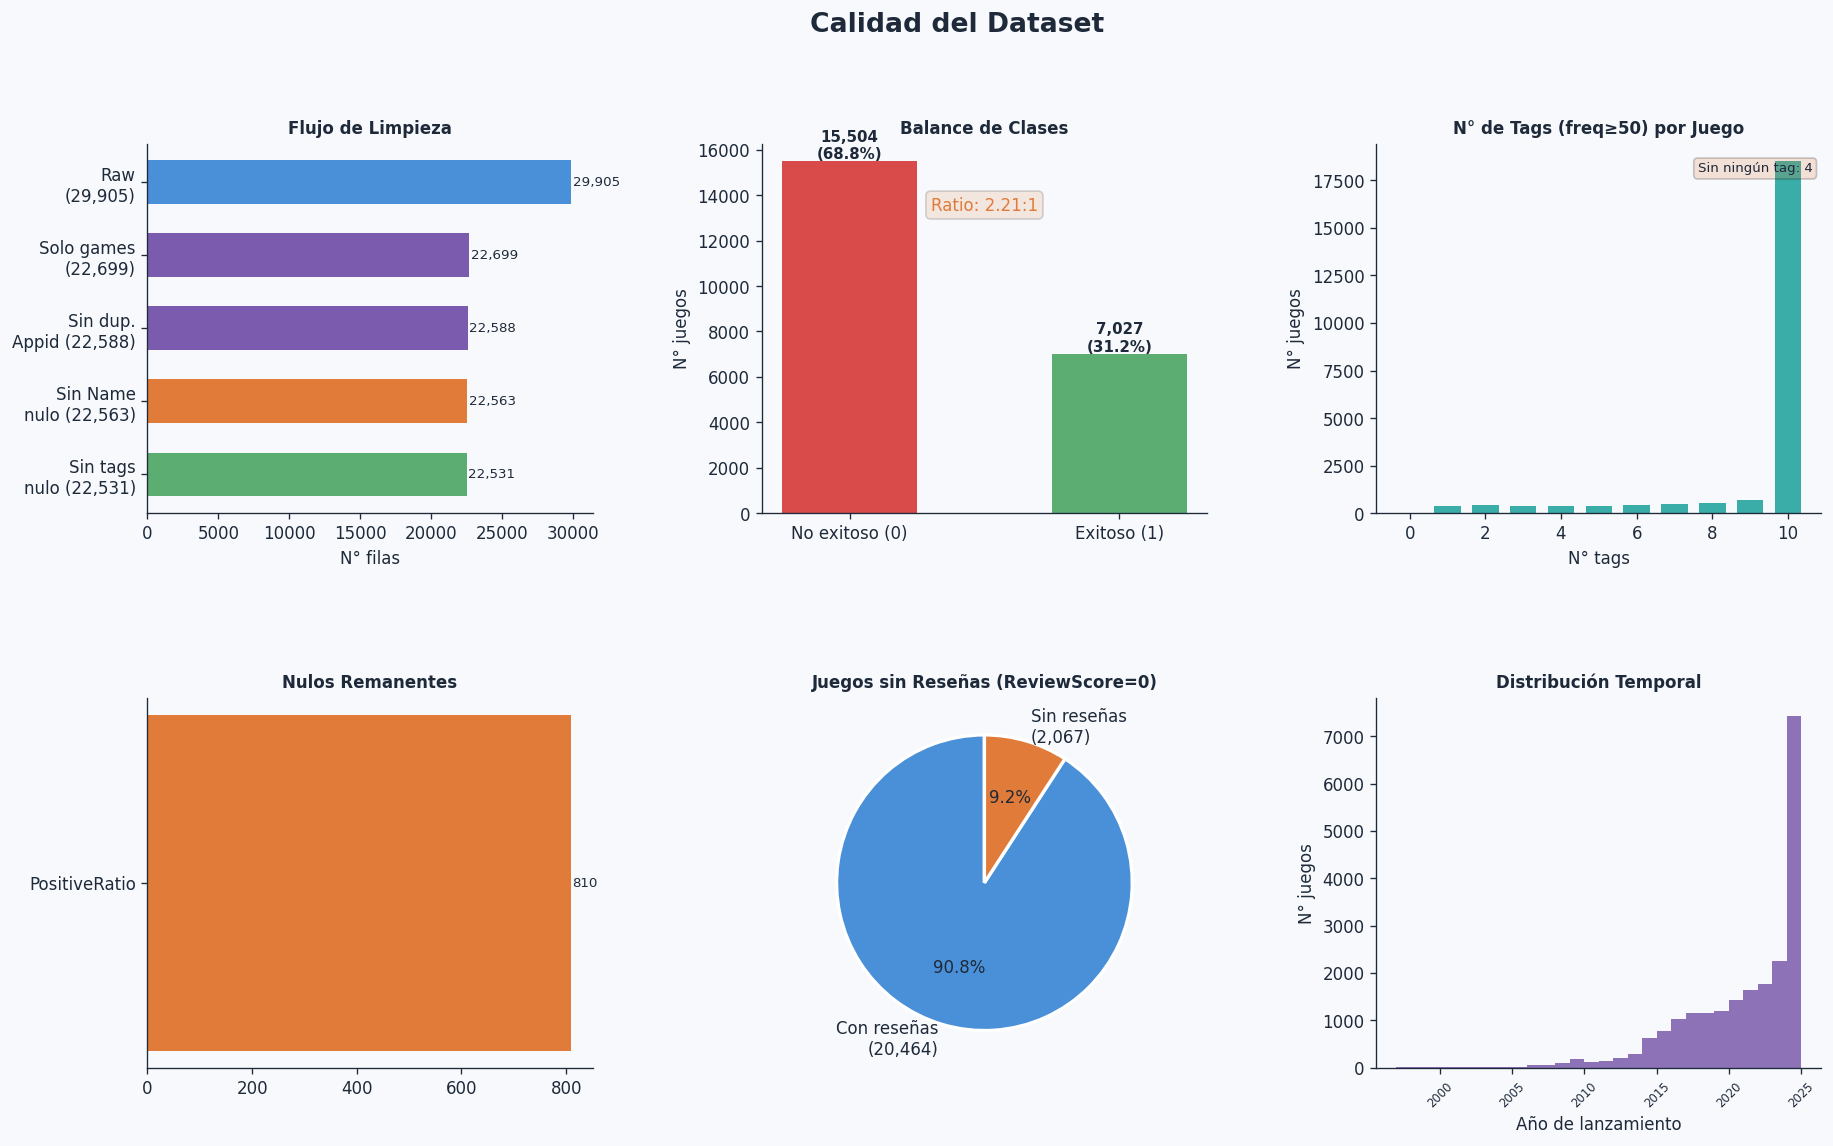

In [14]:
fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('Calidad del Dataset', fontsize=16, fontweight='bold', color=DARK, y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# Flujo de limpieza
ax = fig.add_subplot(gs[0, 0])
steps  = ['Raw\n(29,905)','Solo games\n(22,699)','Sin dup.\nAppid (22,588)',
          'Sin Name\nnulo (22,563)','Sin tags\nnulo (22,531)']
counts_flow = [29905, 22699, 22588, 22563, 22531]
colors_flow = [BLUE, PURPLE, PURPLE, ORANGE, GREEN]
ax.barh(steps[::-1], counts_flow[::-1], color=colors_flow[::-1], edgecolor='none', height=0.6)
ax.set_title('Flujo de Limpieza', fontsize=10, fontweight='bold'); ax.set_xlabel('N° filas')
for i, v in enumerate(counts_flow[::-1]):
    ax.text(v+100, i, f'{v:,}', va='center', fontsize=8)

# Balance de clases
ax = fig.add_subplot(gs[0, 1])
exit_counts = df['Exitoso'].value_counts()
ax.bar(['No exitoso (0)','Exitoso (1)'], exit_counts.values, color=[RED,GREEN], edgecolor='none', width=0.5)
ax.set_title('Balance de Clases', fontsize=10, fontweight='bold'); ax.set_ylabel('N° juegos')
ratio = exit_counts[1]/exit_counts[0]
for i, v in enumerate(exit_counts.values):
    ax.text(i, v+100, f'{v:,}\n({v/exit_counts.sum()*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax.text(0.5, 0.82, f'Ratio: {ratio:.2f}:1', transform=ax.transAxes, ha='center', fontsize=10, color=ORANGE,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=ORANGE, alpha=0.15))

# N° tags por juego
ax = fig.add_subplot(gs[0, 2])
vc = df['n_tags'].clip(upper=10).value_counts().sort_index()
ax.bar(vc.index, vc.values, color=TEAL, edgecolor='none', width=0.7)
ax.set_title('N° de Tags (freq≥50) por Juego', fontsize=10, fontweight='bold')
ax.set_xlabel('N° tags'); ax.set_ylabel('N° juegos')
zero_tags = (df['n_tags']==0).sum()
ax.text(0.98,0.95,f'Sin ningún tag: {zero_tags}', transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=ORANGE, alpha=0.2))

# Nulos remanentes
ax = fig.add_subplot(gs[1, 0])
final_nulls = df.isnull().sum()
final_nulls = final_nulls[final_nulls > 0].sort_values(ascending=True)
if len(final_nulls) > 0:
    ax.barh(final_nulls.index, final_nulls.values, color=ORANGE, edgecolor='none', height=0.6)
    for i, v in enumerate(final_nulls.values):
        ax.text(v+1, i, str(v), va='center', fontsize=8)
else:
    ax.text(0.5,0.5,'✓ Sin valores\nfaltantes', transform=ax.transAxes,
            ha='center', va='center', fontsize=14, color=GREEN, fontweight='bold')
ax.set_title('Nulos Remanentes', fontsize=10, fontweight='bold')

# Juegos sin reseñas
ax = fig.add_subplot(gs[1, 1])
score0 = (df['ReviewScore']==0).sum()
score_rest = len(df) - score0
ax.pie([score_rest, score0], labels=[f'Con reseñas\n({score_rest:,})',f'Sin reseñas\n({score0:,})'],
       colors=[BLUE,ORANGE], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Juegos sin Reseñas (ReviewScore=0)', fontsize=10, fontweight='bold')

# Distribución temporal
ax = fig.add_subplot(gs[1, 2])
year_range = df['ReleaseYear'].dropna()
ax.hist(year_range, bins=range(int(year_range.min()),2026), color=PURPLE, edgecolor='none', alpha=0.85)
ax.set_title('Distribución Temporal', fontsize=10, fontweight='bold')
ax.set_xlabel('Año de lanzamiento'); ax.set_ylabel('N° juegos')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()


**Observaciones de calidad:**
- Se perdió ~24.7% de los datos al filtrar solo `game` — esperado y justificado.
- Los duplicados eran filas casi idénticas; eliminarlos no afecta la representatividad.
- Hay un **desbalance moderado** (68.8% / 31.2%) que deberá considerarse al modelar.
- ~12.8% de juegos no tienen reseñas (`ReviewScore=0`) — su etiqueta `Exitoso=0` es incierta y podría sesgar el modelo. Considerar filtrarlos en la fase de modelado.
- El dataset está concentrado en años recientes (2015–2023), lo que es coherente con el crecimiento de Steam.


---
## Resumen final

| Etapa | Resultado |
|---|---|
| Filas originales | 29,905 |
| Filas finales | 22,531 |
| Columnas originales | 21 |
| Columnas finales | 154 (incluye 134 tag_*) |
| Variable objetivo | `Exitoso` (ReviewScore ≥ 7) |
| Balance de clases | 68.8% / 31.2% |
| Nulos remanentes | Solo en `PositiveRatio` (juegos sin reseñas) |

**Próximo paso:** Modelado predictivo usando las columnas `tag_*` como features.
